In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

print("\nFirst 5 samples:")
print(X[:5])

print("\nFirst 5 targets:")
print(y[:5])

Feature shape: (150, 4)
Target shape: (150,)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First 5 targets:
[0 0 0 0 0]


In [ ]:
df = pd.DataFrame(X, columns=iris.feature_names)

df["target"] = y
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["species"].value_counts())

Dataset shape: (150, 6)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


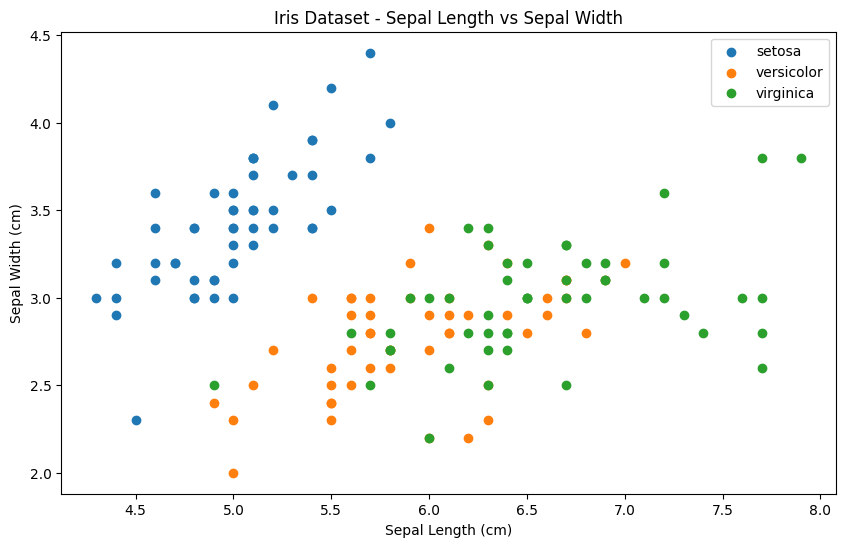

In [ ]:
plt.figure(figsize=(10, 6))

for class_value, class_name in enumerate(iris.target_names):
    plt.scatter(
        X[y == class_value, 0],
        X[y == class_value, 1],
        label=class_name
    )

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Iris Dataset - Sepal Length vs Sepal Width")
plt.legend()
plt.show()

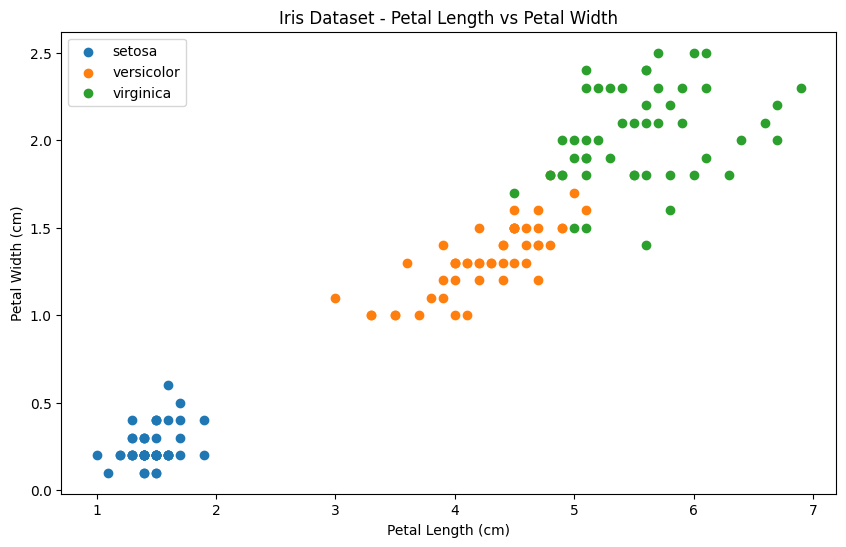

In [ ]:
plt.figure(figsize=(10, 6))

for class_value, class_name in enumerate(iris.target_names):
    plt.scatter(
        X[y == class_value, 2],
        X[y == class_value, 3],
        label=class_name
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Dataset - Petal Length vs Petal Width")
plt.legend()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(np.bincount(y_train))

print("\nTesting class distribution:")
print(np.bincount(y_test))

Training samples: 120
Testing samples: 30

Training class distribution:
[40 40 40]

Testing class distribution:
[10 10 10]


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 scaled training samples:")
print(X_train_scaled[:5])

print("\nMean of scaled training features:")
print(X_train_scaled.mean(axis=0))

print("\nStandard deviation of scaled training features:")
print(X_train_scaled.std(axis=0))

First 5 scaled training samples:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]

Mean of scaled training features:
[-1.20829273e-15 -2.03679666e-15  4.99600361e-16  1.67458640e-15]

Standard deviation of scaled training features:
[1. 1. 1. 1.]


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_encoded = to_categorical(y_train, num_classes=3)
y_test_encoded = to_categorical(y_test, num_classes=3)

print("Original labels:")
print(y_train[:10])

print("\nOne-hot encoded labels:")
print(y_train_encoded[:10])

print("\nEncoded shape:")
print(y_train_encoded.shape)

Original labels:
[0 2 1 0 1 2 1 2 2 2]

One-hot encoded labels:
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]

Encoded shape:
(120, 3)


In [ ]:
model = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    X_train_scaled,
    y_train_encoded,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.3854 - loss: 1.0413 - val_accuracy: 0.2917 - val_loss: 1.1072
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4792 - loss: 0.9943 - val_accuracy: 0.3750 - val_loss: 1.0622
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5208 - loss: 0.9532 - val_accuracy: 0.3750 - val_loss: 1.0238
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5417 - loss: 0.9151 - val_accuracy: 0.3750 - val_loss: 0.9890
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6042 - loss: 0.8801 - val_accuracy: 0.4583 - val_loss: 0.9584
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6042 - loss: 0.8507 - val_accuracy: 0.4583 - val_loss: 0.9294
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6250 - loss: 0.8212 - val_accuracy: 0.5000 - val_loss: 0.9023
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6458 - loss: 0.7947 - val_accuracy: 0.5000 - val_loss

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test_encoded,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.1313
Test Accuracy: 0.9667
Test Accuracy: 96.67%


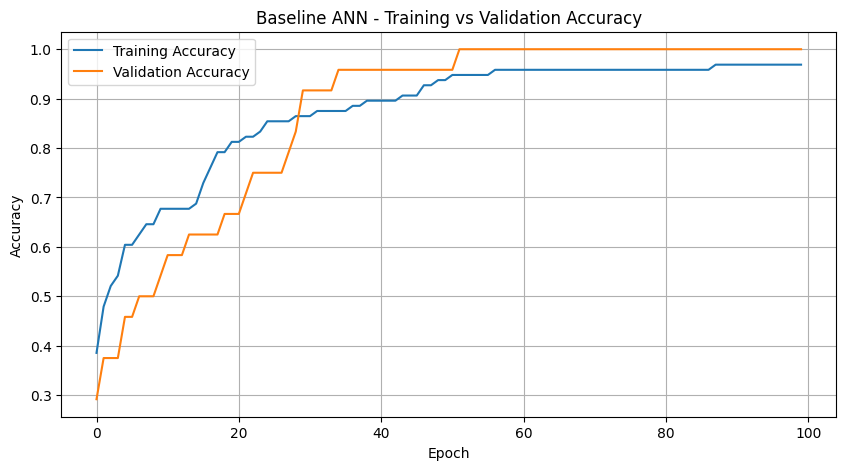

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline ANN - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

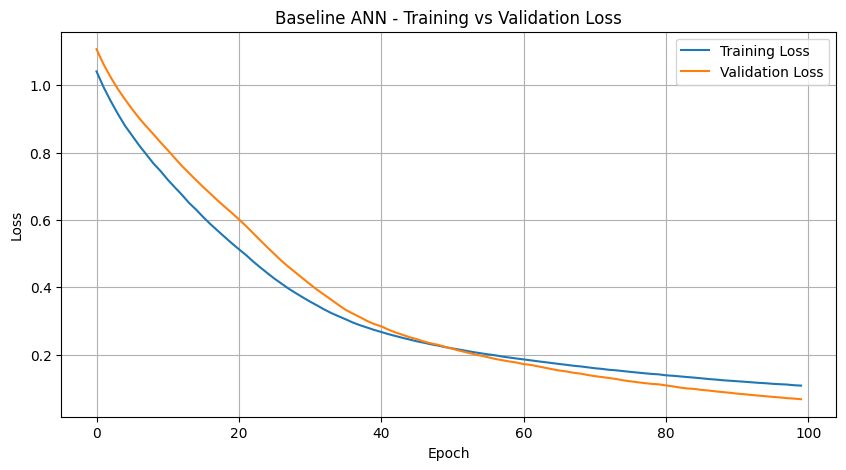

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline ANN - Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def build_and_train_model(activation, epochs=100):
    model = Sequential([
        Dense(16, activation=activation, input_shape=(4,)),
        Dense(8, activation=activation),
        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_scaled,
        y_train_encoded,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        X_test_scaled,
        y_test_encoded,
        verbose=0
    )

    return model, history, test_loss, test_accuracy

In [ ]:
activation_results = {}

for activation in ["relu", "sigmoid", "tanh"]:
    print(f"\nTraining with {activation.upper()} activation...")

    model_temp, history_temp, loss_temp, accuracy_temp = build_and_train_model(
        activation
    )

    activation_results[activation] = {
        "model": model_temp,
        "history": history_temp,
        "loss": loss_temp,
        "accuracy": accuracy_temp
    }

    print(f"Test Accuracy: {accuracy_temp * 100:.2f}%")


Training with RELU activation...
Test Accuracy: 96.67%

Training with SIGMOID activation...
Test Accuracy: 76.67%

Training with TANH activation...
Test Accuracy: 93.33%


In [ ]:
def build_and_train_leaky_relu(epochs=100):
    model = Sequential([
        Dense(16, input_shape=(4,)),
        LeakyReLU(negative_slope=0.01),

        Dense(8),
        LeakyReLU(negative_slope=0.01),

        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_scaled,
        y_train_encoded,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        X_test_scaled,
        y_test_encoded,
        verbose=0
    )

    return model, history, test_loss, test_accuracy

In [ ]:
leaky_model, leaky_history, leaky_loss, leaky_accuracy = (
    build_and_train_leaky_relu()
)

activation_results["leaky_relu"] = {
    "model": leaky_model,
    "history": leaky_history,
    "loss": leaky_loss,
    "accuracy": leaky_accuracy
}

print(f"Leaky ReLU Test Accuracy: {leaky_accuracy * 100:.2f}%")

Leaky ReLU Test Accuracy: 93.33%


In [ ]:
activation_comparison = pd.DataFrame({
    "Activation Function": ["ReLU", "Sigmoid", "Tanh", "Leaky ReLU"],
    "Test Loss": [
        activation_results["relu"]["loss"],
        activation_results["sigmoid"]["loss"],
        activation_results["tanh"]["loss"],
        activation_results["leaky_relu"]["loss"]
    ],
    "Test Accuracy": [
        activation_results["relu"]["accuracy"],
        activation_results["sigmoid"]["accuracy"],
        activation_results["tanh"]["accuracy"],
        activation_results["leaky_relu"]["accuracy"]
    ]
})

activation_comparison["Test Accuracy (%)"] = (
    activation_comparison["Test Accuracy"] * 100
)

activation_comparison = activation_comparison[
    ["Activation Function", "Test Loss", "Test Accuracy (%)"]
]

activation_comparison

,Activation Function,Test Loss,Test Accuracy (%)
0,ReLU,0.168340,96.666664
1,Sigmoid,0.504203,76.666665
2,Tanh,0.151568,93.333334
3,Leaky ReLU,0.148514,93.333334


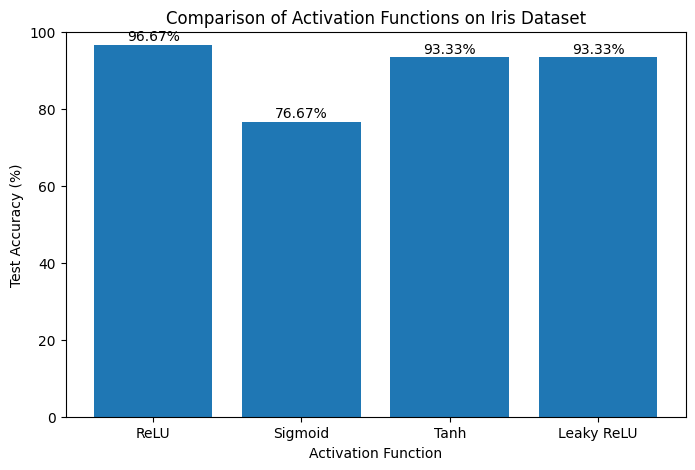

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    activation_comparison["Activation Function"],
    activation_comparison["Test Accuracy (%)"]
)

plt.xlabel("Activation Function")
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of Activation Functions on Iris Dataset")
plt.ylim(0, 100)

for i, value in enumerate(activation_comparison["Test Accuracy (%)"]):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.show()

# Implementing Early Stopping

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
early_model = Sequential([
    tf.keras.Input(shape=(4,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

early_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_history = early_model.fit(
    X_train_scaled,
    y_train_encoded,
    epochs=300,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("Number of epochs actually run:", len(early_history.history["loss"]))

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3229 - loss: 1.1218 - val_accuracy: 0.3750 - val_loss: 1.1034
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3958 - loss: 1.0886 - val_accuracy: 0.4583 - val_loss: 1.0772
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4688 - loss: 1.0578 - val_accuracy: 0.4167 - val_loss: 1.0515
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5729 - loss: 1.0296 - val_accuracy: 0.4583 - val_loss: 1.0268
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6562 - loss: 1.0009 - val_accuracy: 0.5417 - val_loss: 1.0032
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7396 - loss: 0.9736 - val_accuracy: 0.6250 - val_loss: 0.9810
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7708 - loss: 0.9506 - val_accuracy: 0.6667 - val_loss: 0.9615
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7812 - loss: 0.9293 - val_accuracy: 0.6667 - val_loss:

In [ ]:
early_test_loss, early_test_accuracy = early_model.evaluate(
    X_test_scaled,
    y_test_encoded,
    verbose=0
)

print(f"Early Stopping Test Loss: {early_test_loss:.4f}")
print(f"Early Stopping Test Accuracy: {early_test_accuracy:.4f}")
print(f"Early Stopping Test Accuracy: {early_test_accuracy * 100:.2f}%")

print("\nEpochs actually run:", len(early_history.history["loss"]))

Early Stopping Test Loss: 0.0934
Early Stopping Test Accuracy: 0.9667
Early Stopping Test Accuracy: 96.67%

Epochs actually run: 184


In [ ]:
early_stopping_comparison = pd.DataFrame({
    "Model": [
        "Baseline ANN",
        "ANN with Early Stopping"
    ],
    "Maximum Epochs": [
        100,
        300
    ],
    "Actual Epochs": [
        len(history.history["loss"]),
        len(early_history.history["loss"])
    ],
    "Test Loss": [
        test_loss,
        early_test_loss
    ],
    "Test Accuracy (%)": [
        test_accuracy * 100,
        early_test_accuracy * 100
    ]
})

early_stopping_comparison

,Model,Maximum Epochs,Actual Epochs,Test Loss,Test Accuracy (%)
0,Baseline ANN,100,100,0.131267,96.666664
1,ANN with Early Stopping,300,184,0.093411,96.666664


# Hyperparameter Tuning

In [ ]:
def create_model(neurons1=16, neurons2=8, learning_rate=0.001):

    model = Sequential([
        tf.keras.Input(shape=(4,)),
        Dense(neurons1, activation="relu"),
        Dense(neurons2, activation="relu"),
        Dense(3, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
hyperparameter_configs = [
    {
        "neurons1": 8,
        "neurons2": 4,
        "learning_rate": 0.001,
        "batch_size": 16
    },
    {
        "neurons1": 16,
        "neurons2": 8,
        "learning_rate": 0.001,
        "batch_size": 16
    },
    {
        "neurons1": 32,
        "neurons2": 16,
        "learning_rate": 0.001,
        "batch_size": 16
    },
    {
        "neurons1": 32,
        "neurons2": 16,
        "learning_rate": 0.01,
        "batch_size": 16
    },
    {
        "neurons1": 32,
        "neurons2": 16,
        "learning_rate": 0.0001,
        "batch_size": 32
    },
    {
        "neurons1": 64,
        "neurons2": 32,
        "learning_rate": 0.001,
        "batch_size": 32
    }
]

tuning_results = []

for i, config in enumerate(hyperparameter_configs):

    print(f"\nTraining Configuration {i+1}...")

    model_temp = create_model(
        neurons1=config["neurons1"],
        neurons2=config["neurons2"],
        learning_rate=config["learning_rate"]
    )

    history_temp = model_temp.fit(
        X_train_scaled,
        y_train_encoded,
        epochs=100,
        batch_size=config["batch_size"],
        validation_split=0.2,
        verbose=0
    )

    loss_temp, accuracy_temp = model_temp.evaluate(
        X_test_scaled,
        y_test_encoded,
        verbose=0
    )

    tuning_results.append({
        "Configuration": i + 1,
        "Neurons Layer 1": config["neurons1"],
        "Neurons Layer 2": config["neurons2"],
        "Learning Rate": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Test Loss": loss_temp,
        "Test Accuracy": accuracy_temp,
        "Test Accuracy (%)": accuracy_temp * 100
    })

    print(f"Test Accuracy: {accuracy_temp * 100:.2f}%")


Training Configuration 1...
Test Accuracy: 86.67%

Training Configuration 2...
Test Accuracy: 93.33%

Training Configuration 3...
Test Accuracy: 93.33%

Training Configuration 4...
Test Accuracy: 93.33%

Training Configuration 5...
Test Accuracy: 70.00%

Training Configuration 6...
Test Accuracy: 96.67%


In [ ]:
tuning_comparison = pd.DataFrame(tuning_results)

tuning_comparison

,Configuration,Neurons Layer 1,Neurons Layer 2,Learning Rate,Batch Size,Test Loss,Test Accuracy,Test Accuracy (%)
0,1,8,4,0.0010,16,0.332996,0.866667,86.666667
1,2,16,8,0.0010,16,0.167325,0.933333,93.333334
2,3,32,16,0.0010,16,0.117645,0.933333,93.333334
3,4,32,16,0.0100,16,0.220427,0.933333,93.333334
4,5,32,16,0.0001,32,0.833802,0.700000,69.999999
5,6,64,32,0.0010,32,0.087333,0.966667,96.666664


In [ ]:
best_config = tuning_comparison.loc[
    tuning_comparison["Test Accuracy (%)"].idxmax()
]

print("Best Hyperparameter Configuration:\n")
print(best_config)

Best Hyperparameter Configuration:

Configuration         6.000000
Neurons Layer 1      64.000000
Neurons Layer 2      32.000000
Learning Rate         0.001000
Batch Size           32.000000
Test Loss             0.087333
Test Accuracy         0.966667
Test Accuracy (%)    96.666664
Name: 5, dtype: float64


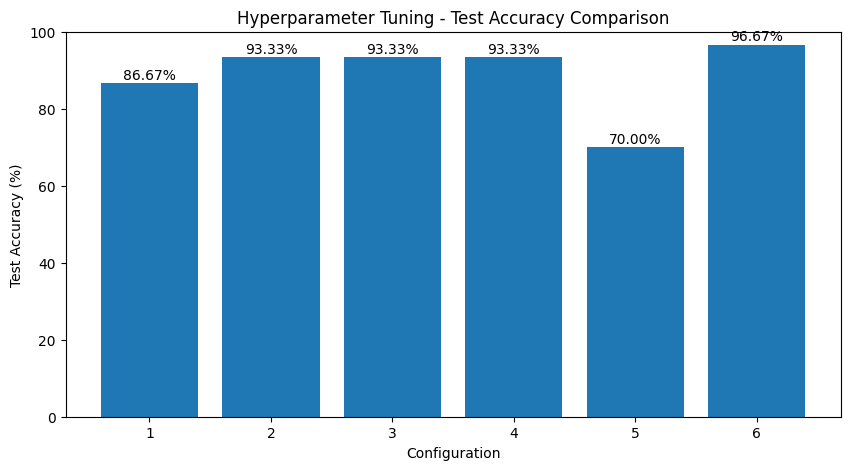

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    tuning_comparison["Configuration"].astype(str),
    tuning_comparison["Test Accuracy (%)"]
)

plt.xlabel("Configuration")
plt.ylabel("Test Accuracy (%)")
plt.title("Hyperparameter Tuning - Test Accuracy Comparison")
plt.ylim(0, 100)

for i, value in enumerate(tuning_comparison["Test Accuracy (%)"]):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.show()

In [ ]:
final_model = create_model(
    neurons1=int(best_config["Neurons Layer 1"]),
    neurons2=int(best_config["Neurons Layer 2"]),
    learning_rate=float(best_config["Learning Rate"])
)

final_history = final_model.fit(
    X_train_scaled,
    y_train_encoded,
    epochs=100,
    batch_size=int(best_config["Batch Size"]),
    validation_split=0.2,
    verbose=0
)

print("Final model trained successfully!")

Final model trained successfully!


In [ ]:
final_test_loss, final_test_accuracy = final_model.evaluate(
    X_test_scaled,
    y_test_encoded,
    verbose=0
)

print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy * 100:.2f}%")

Final Test Loss: 0.1030
Final Test Accuracy: 0.9667
Final Test Accuracy: 96.67%


In [ ]:
y_pred_prob = final_model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_prob, axis=1)

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
First 10 predictions:
[0 2 1 1 0 1 0 0 2 1]

First 10 actual values:
[0 2 1 1 0 1 0 0 2 1]


### Classification Report

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
final_comparison = pd.DataFrame([
    {
        "Experiment": "Baseline ANN",
        "Test Loss": test_loss,
        "Test Accuracy (%)": test_accuracy * 100
    },
    {
        "Experiment": "ReLU",
        "Test Loss": activation_results["relu"]["loss"],
        "Test Accuracy (%)": activation_results["relu"]["accuracy"] * 100
    },
    {
        "Experiment": "Sigmoid",
        "Test Loss": activation_results["sigmoid"]["loss"],
        "Test Accuracy (%)": activation_results["sigmoid"]["accuracy"] * 100
    },
    {
        "Experiment": "Tanh",
        "Test Loss": activation_results["tanh"]["loss"],
        "Test Accuracy (%)": activation_results["tanh"]["accuracy"] * 100
    },
    {
        "Experiment": "Leaky ReLU",
        "Test Loss": activation_results["leaky_relu"]["loss"],
        "Test Accuracy (%)": activation_results["leaky_relu"]["accuracy"] * 100
    },
    {
        "Experiment": "Early Stopping",
        "Test Loss": early_test_loss,
        "Test Accuracy (%)": early_test_accuracy * 100
    },
    {
        "Experiment": "Best Tuned ANN",
        "Test Loss": final_test_loss,
        "Test Accuracy (%)": final_test_accuracy * 100
    }
])

final_comparison

,Experiment,Test Loss,Test Accuracy (%)
0,Baseline ANN,0.131267,96.666664
1,ReLU,0.168340,96.666664
2,Sigmoid,0.504203,76.666665
3,Tanh,0.151568,93.333334
4,Leaky ReLU,0.148514,93.333334
5,Early Stopping,0.093411,96.666664
6,Best Tuned ANN,0.103014,96.666664


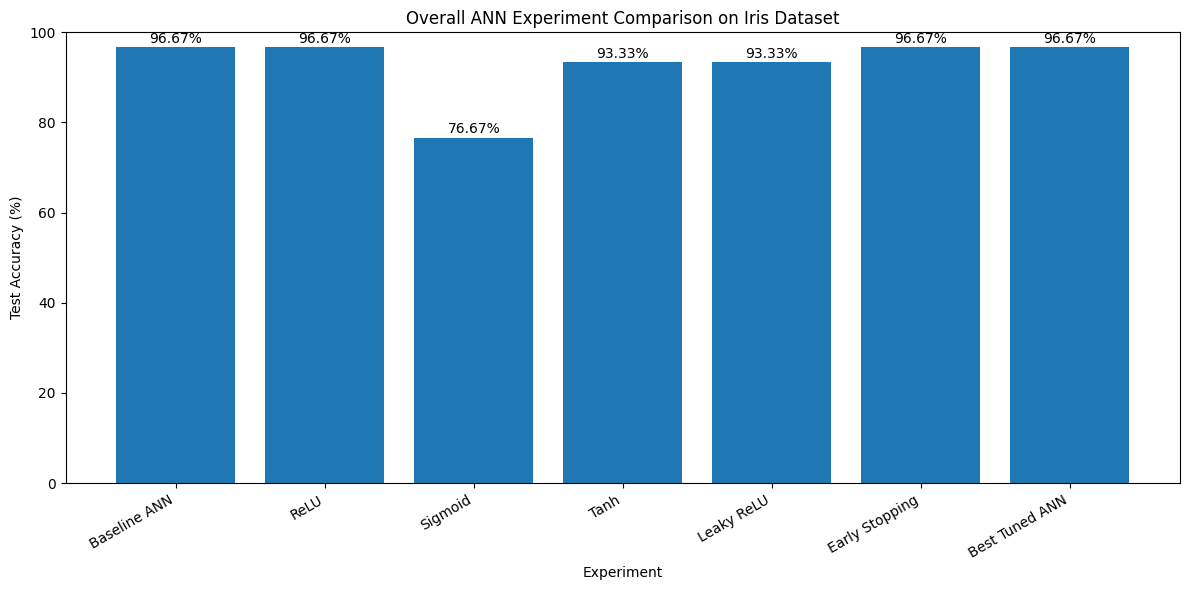

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_comparison["Experiment"],
    final_comparison["Test Accuracy (%)"]
)

plt.xlabel("Experiment")
plt.ylabel("Test Accuracy (%)")
plt.title("Overall ANN Experiment Comparison on Iris Dataset")
plt.ylim(0, 100)

plt.xticks(rotation=30, ha="right")

for i, value in enumerate(final_comparison["Test Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()